In [12]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/ai-tudy/finale/pipeline_detected_family_image

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/ai-tudy/finale/pipeline_detected_family_image


In [13]:
import sys
import pandas as pd
sys.path.insert(0, './utils/')
from dataset import ConvDataset
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt

In [14]:
dataset_result = ConvDataset('result/result_0')

In [15]:
def extract_number(path_str):
  filename_without_ext = Path(path_str).stem
  number_str = filename_without_ext.split('_')[-1]
  return int(number_str)



In [16]:
df = pd.DataFrame(dataset_result.samples, columns=['img_path', 'label'])

In [17]:
df['temp_num'] = df['img_path'].apply(extract_number)


df = df.sort_values(by='temp_num').reset_index(drop=True).drop(columns=['temp_num'])

df_correct = df[df['label'] == dataset_result.dict_class_label['correct']].reset_index(drop=True)
df_defect = df[df['label'] == dataset_result.dict_class_label['defect']].reset_index(drop=True)
df_correct.head()

,img_path,label
0,result/result_0/correct/correct_0.jpg,1
1,result/result_0/correct/correct_1.jpg,1
2,result/result_0/correct/correct_2.jpg,1
3,result/result_0/correct/correct_3.jpg,1
4,result/result_0/correct/correct_4.jpg,1


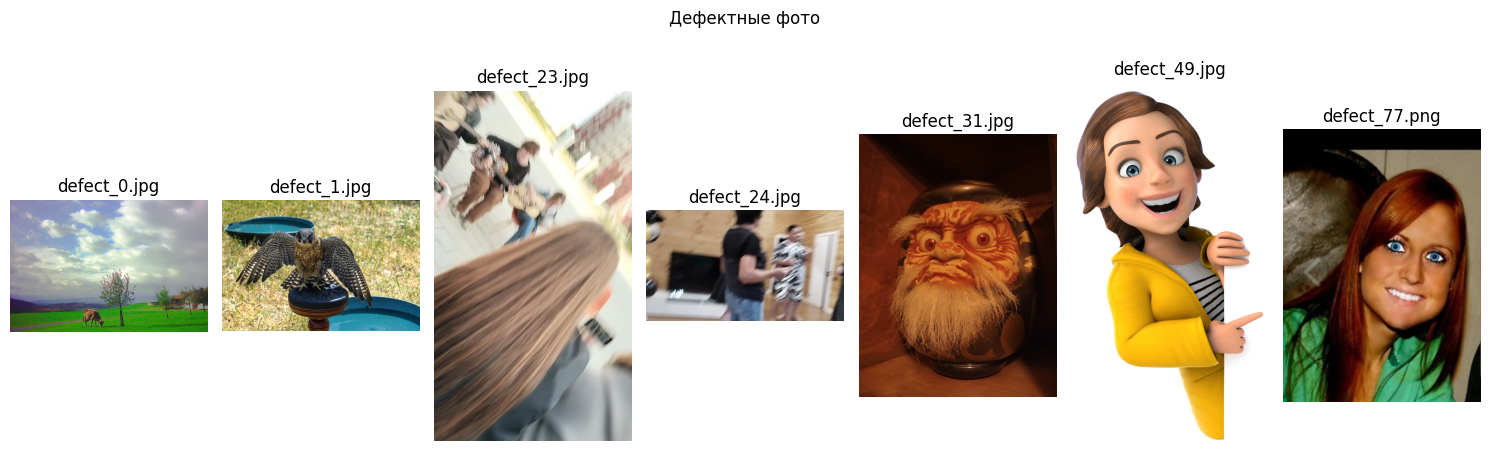

In [18]:
img_path_list = [
    df_defect.loc[0, 'img_path'],
    df_defect.loc[1, 'img_path'],
    df_defect.loc[23, 'img_path'],
    df_defect.loc[24, 'img_path'],
    df_defect.loc[31, 'img_path'],
    df_defect.loc[49, 'img_path'],
    df_defect.loc[77, 'img_path']

]

fig, axes = plt.subplots(1, len(img_path_list), figsize=(15, 5))
fig.suptitle('Дефектные фото')
for i, img_path in enumerate(img_path_list):
    axes[i].imshow(Image.open(img_path))
    axes[i].set_title(f"{Path(img_path).name}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

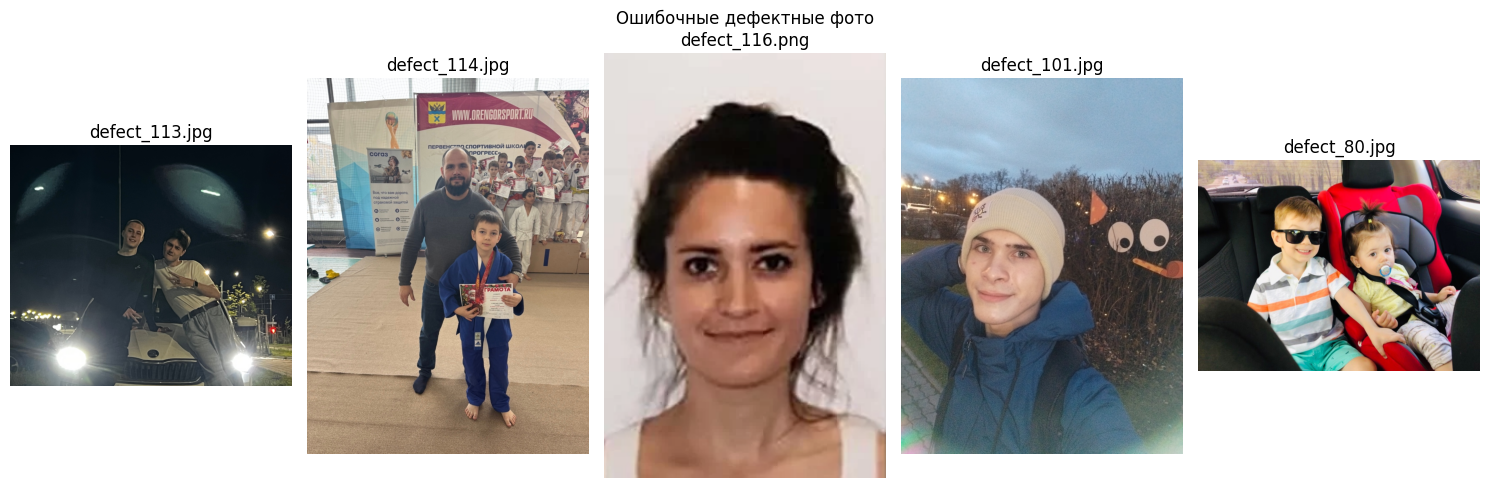

In [20]:
img_path_list = [
    df_defect.loc[113, 'img_path'],
    df_defect.loc[114, 'img_path'],
    df_defect.loc[116, 'img_path'],
    df_defect.loc[101, 'img_path'],
    df_defect.loc[80, 'img_path']
]

fig, axes = plt.subplots(1, len(img_path_list), figsize=(15, 5))
fig.suptitle('Ошибочные дефектные фото')
for i, img_path in enumerate(img_path_list):
    axes[i].imshow(Image.open(img_path))
    axes[i].set_title(f"{Path(img_path).name}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

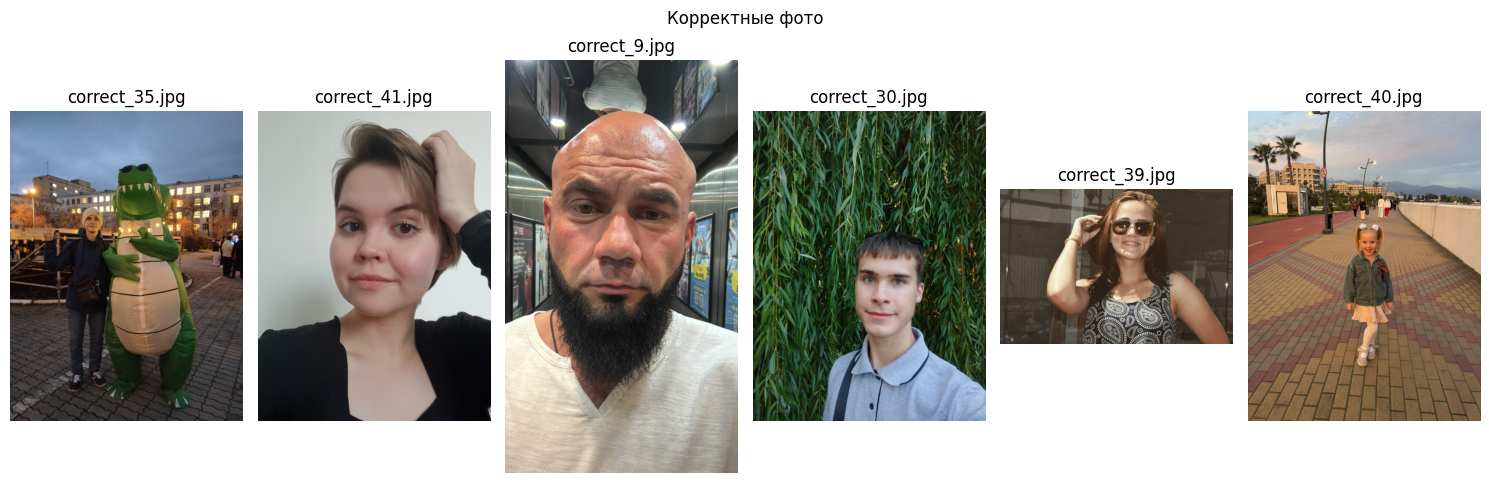

In [24]:
img_path_list = [
    df_correct.loc[35, 'img_path'],
    df_correct.loc[41, 'img_path'],
    df_correct.loc[9, 'img_path'],
    df_correct.loc[30, 'img_path'],
    df_correct.loc[39, 'img_path'],
    df_correct.loc[40, 'img_path']
]

fig, axes = plt.subplots(1, len(img_path_list), figsize=(15, 5))
fig.suptitle('Корректные фото')
for i, img_path in enumerate(img_path_list):
    axes[i].imshow(Image.open(img_path))
    axes[i].set_title(f"{Path(img_path).name}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

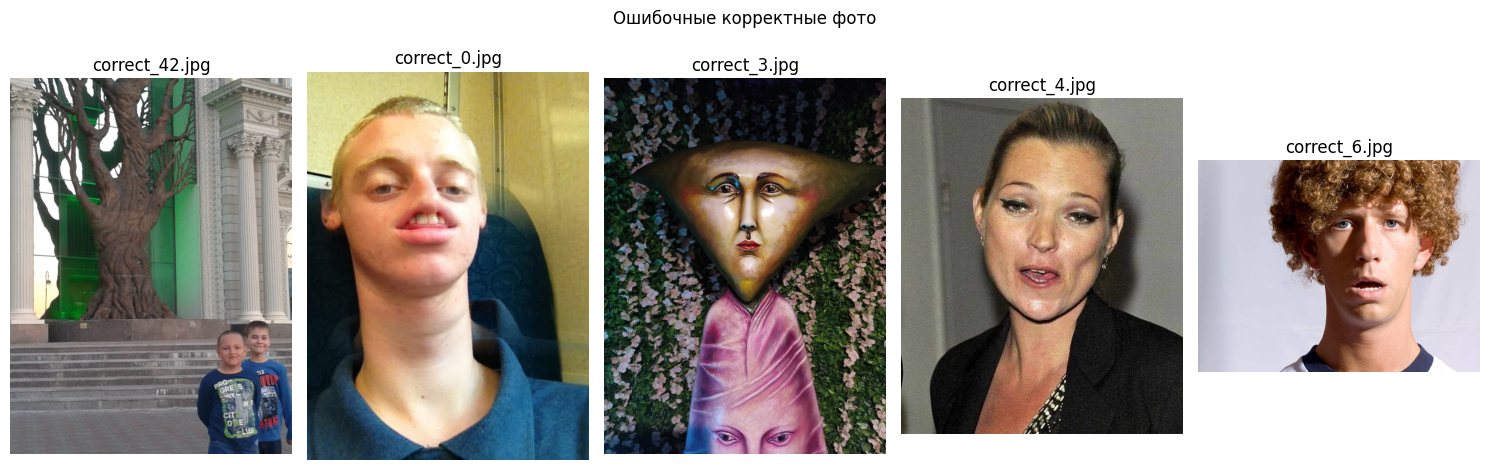

In [26]:
img_path_list = [
    df_correct.loc[42, 'img_path'],
    df_correct.loc[0, 'img_path'],
    df_correct.loc[3, 'img_path'],
    df_correct.loc[4, 'img_path'],
    df_correct.loc[6, 'img_path']
]

fig, axes = plt.subplots(1, len(img_path_list), figsize=(15, 5))
fig.suptitle('Ошибочные корректные фото')
for i, img_path in enumerate(img_path_list):
    axes[i].imshow(Image.open(img_path))
    axes[i].set_title(f"{Path(img_path).name}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()